--- Local Outlier Factor (LOF) pe GPU via PyTorch ---
PyTorch version: 2.11.0+cu130
CUDA available: True
Dispozitiv detectat: cuda
[*] Date încărcate pentru antrenare (Benigne 2017): 345659 rânduri.
[*] Date încărcate pentru testare (Total 2017): 100250 rânduri.
Antrenare LOF pe GPU finalizată în 16.73s

1. RAPORT FINAL DE AUDIT (LOF GPU):
SISTEM AUDIT SSH - REZULTATE LOCAL OUTLIER FACTOR (LOF) pe GPU
Scor AUC: 0.9063
              precision    recall  f1-score   support

      Normal       0.97      0.85      0.90     86415
    Anomalie       0.47      0.85      0.60     13835

    accuracy                           0.85    100250
   macro avg       0.72      0.85      0.75    100250
weighted avg       0.90      0.85      0.86    100250



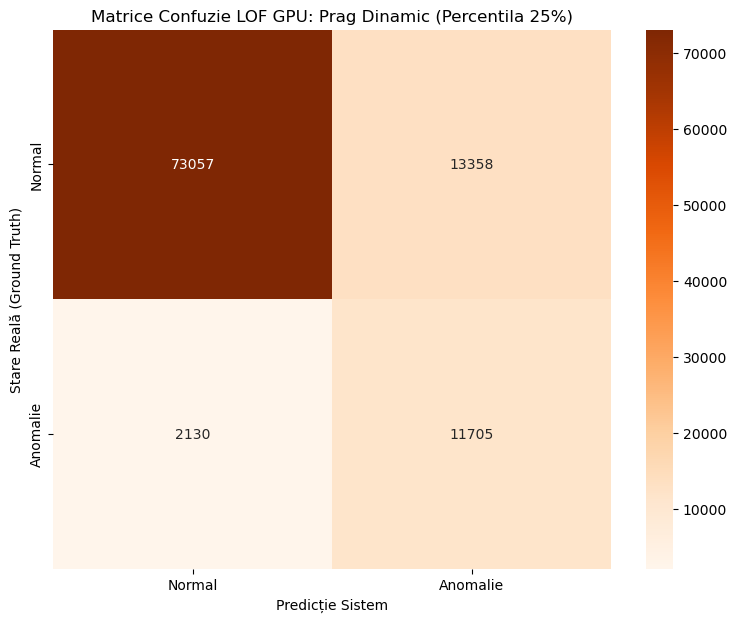

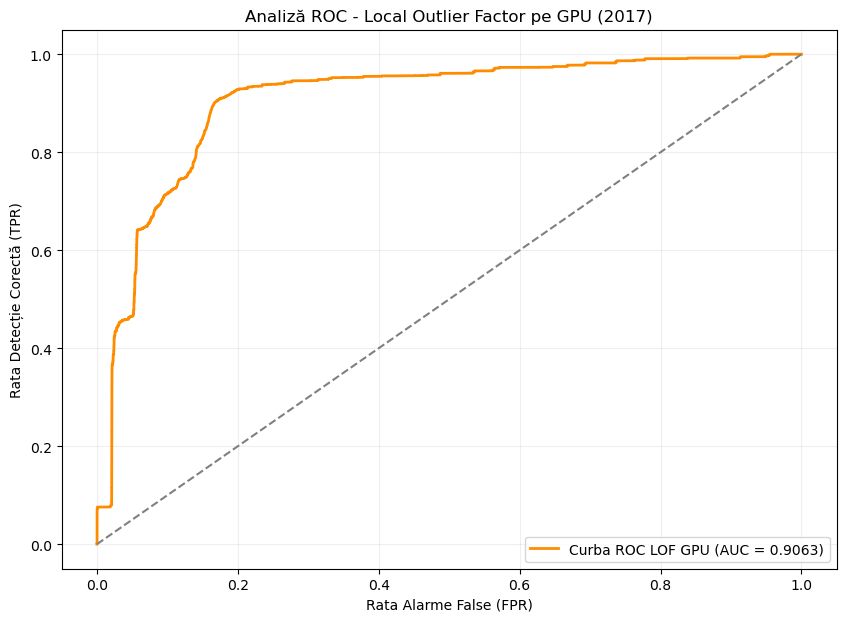


Rezultatele și artefactele LOF au fost salvate în: D:\disertatie\rezultate_2017\LOF


In [1]:
import sys
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

prepro_path = r'D:\disertatie\preprocesare_anomalii_2017'
model_save_path = r'D:\disertatie\modele_2017\LOF'
rezultate_path = r'D:\disertatie\rezultate_2017\LOF'

for p in [model_save_path, rezultate_path]:
    os.makedirs(p, exist_ok=True)

print("--- Local Outlier Factor (LOF) pe GPU via PyTorch ---")
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print(f"Dispozitiv detectat: {device}")

X_train_tensor = torch.load(os.path.join(prepro_path, 'X_train_anomalii.pt'), map_location=device).float()
X_test_tensor = torch.load(os.path.join(prepro_path, 'X_test_anomalii.pt'), map_location=device).float()
y_test_tensor = torch.load(os.path.join(prepro_path, 'y_test_anomalii.pt'), map_location=device)
print(f"[*] Date încărcate pentru antrenare (Benigne 2017): {X_train_tensor.shape[0]} rânduri.")
print(f"[*] Date încărcate pentru testare (Total 2017): {X_test_tensor.shape[0]} rânduri.")
y_test_cpu = y_test_tensor.cpu().numpy()

def compute_knn_gpu(X_target, X_source, k):
    n_target = X_target.shape[0]
    n_source = X_source.shape[0]
    distances = torch.zeros((n_target, k), device=device)
    indices = torch.zeros((n_target, k), dtype=torch.long, device=device)
    
    batch_size = 5000
    for i in range(0, n_target, batch_size):
        end_i = min(i + batch_size, n_target)
        X_batch = X_target[i:end_i]
        dist_matrix = torch.cdist(X_batch, X_source, p=2)
        topk_dist, topk_idx = torch.topk(dist_matrix, k=k, largest=False, dim=1)
        distances[i:end_i] = topk_dist
        indices[i:end_i] = topk_idx
    return distances, indices

def fit_lof_gpu(X_train, k=35):
    dist_train, idx_train = compute_knn_gpu(X_train, X_train, k + 1)
    dist_train = dist_train[:, 1:]
    idx_train = idx_train[:, 1:]
    k_dist = dist_train[:, -1]
    n_samples = X_train.shape[0]
    lrd = torch.zeros(n_samples, device=device)
    
    batch_size = 5000
    for i in range(0, n_samples, batch_size):
        end_i = min(i + batch_size, n_samples)
        neighbors_idx = idx_train[i:end_i]
        neighbors_k_dist = k_dist[neighbors_idx]
        actual_dists = dist_train[i:end_i]
        reach_dists = torch.max(actual_dists, neighbors_k_dist)
        sum_reach_dist = torch.sum(reach_dists, dim=1)
        lrd[i:end_i] = k / (sum_reach_dist + 1e-10)
    return k_dist, lrd, X_train

def predict_lof_gpu(X_test, k_dist_train, lrd_train, X_train, k=35):
    dist_test, idx_test = compute_knn_gpu(X_test, X_train, k)
    n_test = X_test.shape[0]
    lrd_test = torch.zeros(n_test, device=device)
    
    batch_size = 5000
    for i in range(0, n_test, batch_size):
        end_i = min(i + batch_size, n_test)
        neighbors_idx = idx_test[i:end_i]
        neighbors_k_dist = k_dist_train[neighbors_idx]
        actual_dists = dist_test[i:end_i]
        reach_dists = torch.max(actual_dists, neighbors_k_dist)
        sum_reach_dist = torch.sum(reach_dists, dim=1)
        lrd_test[i:end_i] = k / (sum_reach_dist + 1e-10)
        
    lof_scores = torch.zeros(n_test, device=device)
    for i in range(0, n_test, batch_size):
        end_i = min(i + batch_size, n_test)
        neighbors_idx = idx_test[i:end_i]
        lrd_neighbors = lrd_train[neighbors_idx]
        lrd_self = lrd_test[i:end_i].unsqueeze(1)
        lof_scores[i:end_i] = torch.mean(lrd_neighbors / (lrd_self + 1e-10), dim=1)
    return -(lof_scores - 1.0)

start_time = time.time()
k_dist_train, lrd_train, _ = fit_lof_gpu(X_train_tensor, k=35)
print(f"Antrenare LOF pe GPU finalizată în {time.time() - start_time:.2f}s")

decision_scores_tensor = predict_lof_gpu(X_test_tensor, k_dist_train, lrd_train, X_train_tensor, k=35)
decision_scores = decision_scores_tensor.cpu().numpy()

percentila_dorita = 25 
prag_dinamic = np.percentile(decision_scores, percentila_dorita)
y_pred = [1 if x < prag_dinamic else 0 for x in decision_scores]

y_scores = -decision_scores 
fpr, tpr, _ = roc_curve(y_test_cpu, y_scores)
roc_auc = auc(fpr, tpr)

report = classification_report(y_test_cpu, y_pred, target_names=['Normal', 'Anomalie'])
full_report_text = f"SISTEM AUDIT SSH - REZULTATE LOCAL OUTLIER FACTOR (LOF) pe GPU\n"
full_report_text += f"Scor AUC: {roc_auc:.4f}\n"
full_report_text += "="*50 + "\n"
full_report_text += report

print("\n1. RAPORT FINAL DE AUDIT (LOF GPU):")
print(full_report_text)

with open(os.path.join(rezultate_path, 'raport_final_lof_gpu.txt'), 'w') as f:
    f.write(full_report_text)

plt.figure(figsize=(9, 7))
cm = confusion_matrix(y_test_cpu, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'])
plt.title(f'Matrice Confuzie LOF GPU: Prag Dinamic (Percentila {percentila_dorita}%)')
plt.ylabel('Stare Reală (Ground Truth)')
plt.xlabel('Predicție Sistem')
plt.savefig(os.path.join(rezultate_path, 'matrice_confuzie_lof_gpu.png'), dpi=300)
plt.show()

plt.figure(figsize=(10, 7))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curba ROC LOF GPU (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Rata Alarme False (FPR)')
plt.ylabel('Rata Detecție Corectă (TPR)')
plt.title('Analiză ROC - Local Outlier Factor pe GPU (2017)')
plt.legend(loc="lower right")
plt.grid(alpha=0.2)
plt.savefig(os.path.join(rezultate_path, 'curba_roc_lof_gpu.png'), dpi=300)
plt.show()

model_data = {
    'k_dist_train': k_dist_train.cuda(),
    'lrd_train': lrd_train.cuda(),
    'X_train': X_train_tensor.cuda(),
    'k': 35
}
joblib.dump(model_data, os.path.join(model_save_path, 'model_lof_final_gpu.pkl'))
print(f"\nRezultatele și artefactele LOF au fost salvate în: {rezultate_path}")